### 1. Import Libraries

In [28]:
import pandas as pd
import numpy as np
import math
import os
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")


from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.preprocessing import MinMaxScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

from statsmodels.stats.outliers_influence import variance_inflation_factor

import joblib

from scipy import stats

In [29]:
# Load the data
file_path = "oasis_longitudinal_demographics-8d83e569fa2e2d30.xlsx"
df = pd.read_excel(file_path)

### 2. Data Inspection

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 373 entries, 0 to 372
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Subject ID  373 non-null    object 
 1   MRI ID      373 non-null    object 
 2   Group       373 non-null    object 
 3   Visit       373 non-null    int64  
 4   MR Delay    373 non-null    int64  
 5   M/F         373 non-null    object 
 6   Hand        373 non-null    object 
 7   Age         373 non-null    int64  
 8   EDUC        373 non-null    int64  
 9   SES         354 non-null    float64
 10  MMSE        371 non-null    float64
 11  CDR         373 non-null    float64
 12  eTIV        373 non-null    float64
 13  nWBV        373 non-null    float64
 14  ASF         373 non-null    float64
dtypes: float64(6), int64(4), object(5)
memory usage: 43.8+ KB


In [31]:
df.isna().sum()

Subject ID     0
MRI ID         0
Group          0
Visit          0
MR Delay       0
M/F            0
Hand           0
Age            0
EDUC           0
SES           19
MMSE           2
CDR            0
eTIV           0
nWBV           0
ASF            0
dtype: int64

In [32]:
df.shape

(373, 15)

In [33]:
df.describe()

,Visit,MR Delay,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
count,373.000000,373.000000,373.000000,373.000000,354.000000,371.000000,373.000000,373.000000,373.000000,373.000000
mean,1.882038,595.104558,77.013405,14.597855,2.460452,27.342318,0.290885,1488.121584,0.729556,1.195460
std,0.922843,635.485118,7.640957,2.876339,1.134005,3.683244,0.374557,176.135956,0.037141,0.138105
min,1.000000,0.000000,60.000000,6.000000,1.000000,4.000000,0.000000,1105.652499,0.644399,0.875539
25%,1.000000,0.000000,71.000000,12.000000,2.000000,27.000000,0.000000,1357.330000,0.700191,1.098979
50%,2.000000,552.000000,77.000000,15.000000,2.000000,29.000000,0.000000,1470.041312,0.728789,1.193844
75%,2.000000,873.000000,82.000000,16.000000,3.000000,30.000000,0.500000,1596.936793,0.755669,1.292980
max,5.000000,2639.000000,98.000000,23.000000,5.000000,30.000000,2.000000,2004.479526,0.836842,1.587298


In [34]:
df['Subject ID'].nunique()

150

In [35]:
for column in  df.columns:
    print('---'*30)
    print(f'Column Name: {column}')
    print(f'Unique Values Count: {df[column].nunique()}')
    print(f'Unique values: {df[column].unique()}')
    print('---'*30)

------------------------------------------------------------------------------------------
Column Name: Subject ID
Unique Values Count: 150
Unique values: ['OAS2_0001' 'OAS2_0002' 'OAS2_0004' 'OAS2_0005' 'OAS2_0007' 'OAS2_0008'
 'OAS2_0009' 'OAS2_0010' 'OAS2_0012' 'OAS2_0013' 'OAS2_0014' 'OAS2_0016'
 'OAS2_0017' 'OAS2_0018' 'OAS2_0020' 'OAS2_0021' 'OAS2_0022' 'OAS2_0023'
 'OAS2_0026' 'OAS2_0027' 'OAS2_0028' 'OAS2_0029' 'OAS2_0030' 'OAS2_0031'
 'OAS2_0032' 'OAS2_0034' 'OAS2_0035' 'OAS2_0036' 'OAS2_0037' 'OAS2_0039'
 'OAS2_0040' 'OAS2_0041' 'OAS2_0042' 'OAS2_0043' 'OAS2_0044' 'OAS2_0045'
 'OAS2_0046' 'OAS2_0047' 'OAS2_0048' 'OAS2_0049' 'OAS2_0050' 'OAS2_0051'
 'OAS2_0052' 'OAS2_0053' 'OAS2_0054' 'OAS2_0055' 'OAS2_0056' 'OAS2_0057'
 'OAS2_0058' 'OAS2_0060' 'OAS2_0061' 'OAS2_0062' 'OAS2_0063' 'OAS2_0064'
 'OAS2_0066' 'OAS2_0067' 'OAS2_0068' 'OAS2_0069' 'OAS2_0070' 'OAS2_0071'
 'OAS2_0073' 'OAS2_0075' 'OAS2_0076' 'OAS2_0077' 'OAS2_0078' 'OAS2_0079'
 'OAS2_0080' 'OAS2_0081' 'OAS2_0085' 'OAS2

##### Below column should be dropped:

- Hand (Contains only single unique value)

In [36]:
df.columns

Index(['Subject ID', 'MRI ID', 'Group', 'Visit', 'MR Delay', 'M/F', 'Hand',
       'Age', 'EDUC', 'SES', 'MMSE', 'CDR', 'eTIV', 'nWBV', 'ASF'],
      dtype='object')

In [37]:
df.columns = [col.replace(' ','_') for col in df.columns]

In [38]:
df.columns

Index(['Subject_ID', 'MRI_ID', 'Group', 'Visit', 'MR_Delay', 'M/F', 'Hand',
       'Age', 'EDUC', 'SES', 'MMSE', 'CDR', 'eTIV', 'nWBV', 'ASF'],
      dtype='object')

In [39]:
columns_to_be_dropped = ['Hand']
df.drop(columns=columns_to_be_dropped, inplace=True)

In [40]:
df.columns

Index(['Subject_ID', 'MRI_ID', 'Group', 'Visit', 'MR_Delay', 'M/F', 'Age',
       'EDUC', 'SES', 'MMSE', 'CDR', 'eTIV', 'nWBV', 'ASF'],
      dtype='object')

In [41]:
df['Group'].value_counts()

Group
Nondemented    190
Demented       146
Converted       37
Name: count, dtype: int64

### 3. Data Cleaning & Preprocessing

In [42]:
# Target values can be created using the column Group

df['target'] = df['Group'].map({
    'Nondemented': 0,
    'Demented': 1,
    'Converted': 1
})

In [43]:
df['target'].value_counts()

target
0    190
1    183
Name: count, dtype: int64

In [44]:
df.isnull().sum()

Subject_ID     0
MRI_ID         0
Group          0
Visit          0
MR_Delay       0
M/F            0
Age            0
EDUC           0
SES           19
MMSE           2
CDR            0
eTIV           0
nWBV           0
ASF            0
target         0
dtype: int64

In [45]:
df['SES'].value_counts()

SES
2.0    103
1.0     88
3.0     82
4.0     74
5.0      7
Name: count, dtype: int64

In [46]:
df['MMSE'].value_counts()

MMSE
30.0    114
29.0     91
28.0     45
27.0     32
26.0     20
25.0     12
21.0     11
23.0     11
20.0      7
22.0      7
17.0      5
24.0      4
16.0      3
19.0      3
15.0      2
18.0      2
4.0       1
7.0       1
Name: count, dtype: int64

In [47]:
# Null values should be handled before doing EDA

df["SES"] = df["SES"].fillna(df["SES"].median())
df["MMSE"] = df["MMSE"].fillna(df["MMSE"].mean())

In [48]:
df.isna().sum()

Subject_ID    0
MRI_ID        0
Group         0
Visit         0
MR_Delay      0
M/F           0
Age           0
EDUC          0
SES           0
MMSE          0
CDR           0
eTIV          0
nWBV          0
ASF           0
target        0
dtype: int64

### 4. Exploratory-Data-Analysis

#### 4.1 - Univariate & Bi-Variate Analysis

##### Column names used for countplot
- Group
- Visit
- M/F
- SES
- CDR
- EDUC
- M/F

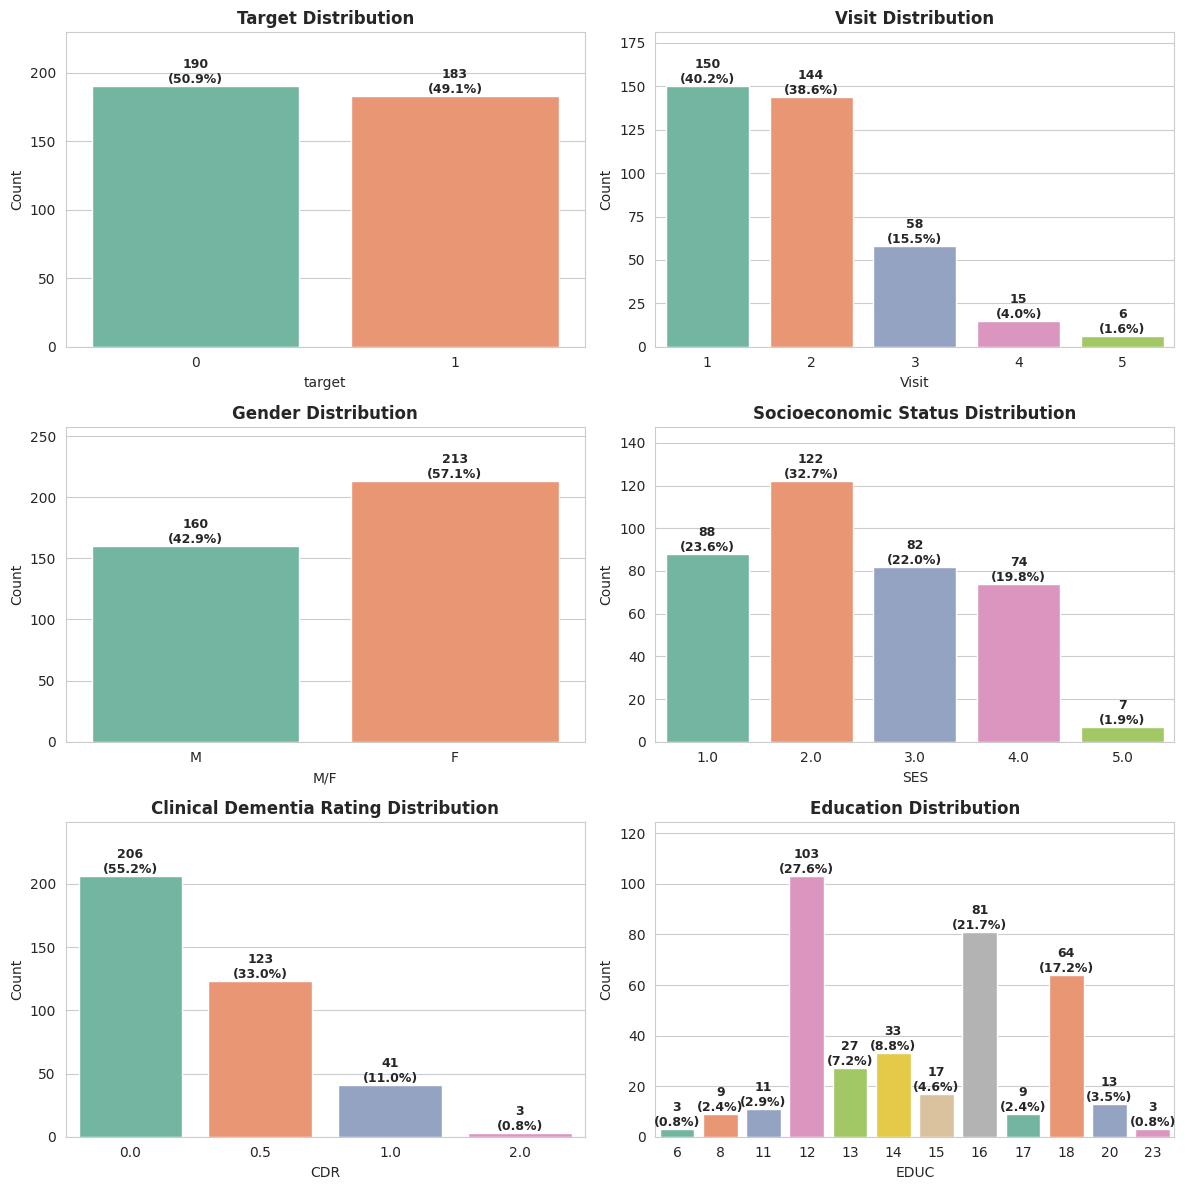

In [49]:
sns.set_style("whitegrid")

def countplot_with_percentage(ax, data, column, title):

    plot = sns.countplot(
        x=column,
        data=data,
        palette="Set2",
        ax=ax
    )

    total = len(data)

    for p in plot.patches:
        count = int(p.get_height())
        percentage = f"{100 * count / total:.1f}%"

        ax.annotate(
            f'{count}\n({percentage})',
            (p.get_x() + p.get_width()/2., count),
            ha='center',
            va='bottom',
            fontsize=9,
            fontweight='bold'
        )

    ymax = ax.get_ylim()[1]
    ax.set_ylim(0, ymax * 1.15)

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel(column)
    ax.set_ylabel("Count")


columns_titles = [
    ('target', 'Target Distribution'),
    ('Visit', 'Visit Distribution'),
    ('M/F', 'Gender Distribution'),
    ('SES', 'Socioeconomic Status Distribution'),
    ('CDR', 'Clinical Dementia Rating Distribution'),
    ('EDUC', 'Education Distribution'),
    
]

n = len(columns_titles)
rows = math.ceil(n / 2)

fig, axes = plt.subplots(rows, 2, figsize=(12, rows * 4))
axes = axes.flatten()

for i, (col, title) in enumerate(columns_titles):
    countplot_with_percentage(axes[i], df, col, title)

# Remove extra empty subplot if odd number
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

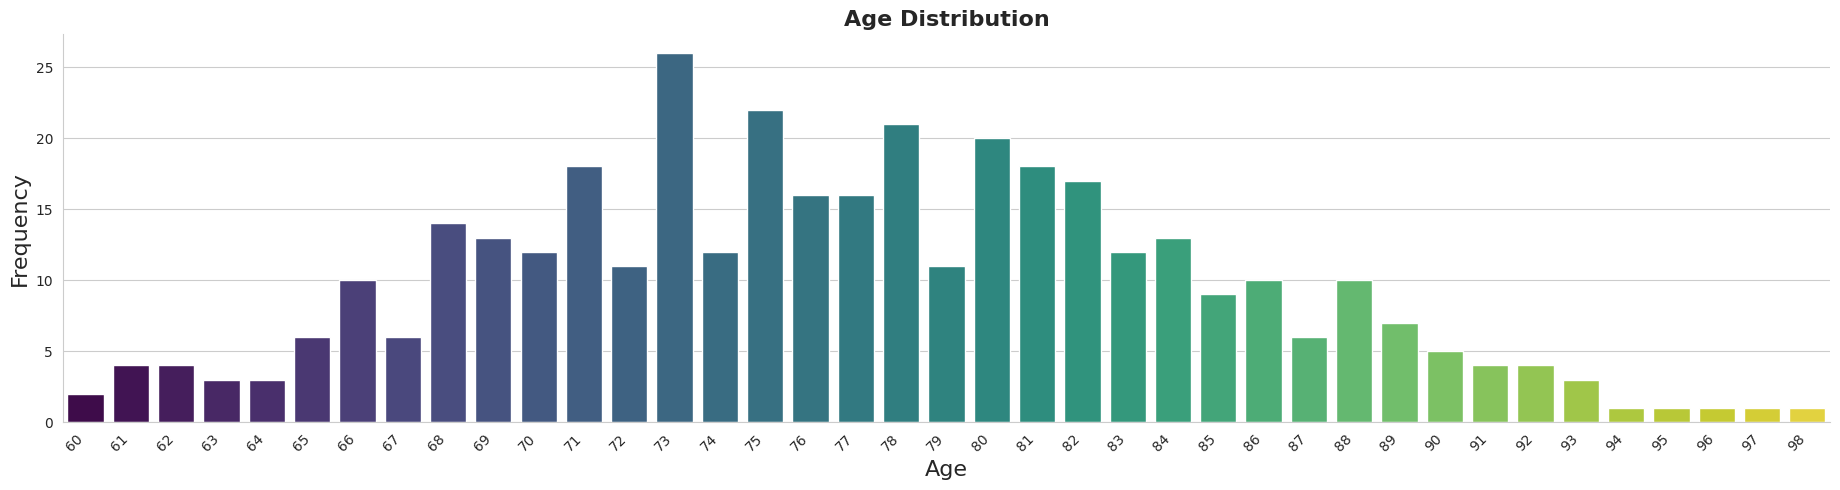

In [50]:
ax = sns.countplot(x="Age", data=df, hue="Age", palette="viridis", legend=False)

ax.figure.set_size_inches(18.5, 5)

ax.set_title("Age Distribution", fontsize=16, fontweight="bold")
ax.set_xlabel("Age", fontsize=16)
ax.set_ylabel("Frequency", fontsize=16)

plt.xticks(rotation=45, ha="right")

sns.despine()
plt.tight_layout()
plt.show()

In [51]:
df['Visit'].unique()

array([1, 2, 3, 4, 5])

##### 4.2 - Outlier Detection

- Z-Score
- IQR
- Boxplot
- Distribution

In [52]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

print("Numerical Columns:")
print(num_cols)

Numerical Columns:
Index(['Visit', 'MR_Delay', 'Age', 'EDUC', 'SES', 'MMSE', 'CDR', 'eTIV',
       'nWBV', 'ASF', 'target'],
      dtype='object')


In [53]:
def detect_outliers_zscore(data, columns, threshold=3):

    outlier_dict = {}

    for col in columns:
        z = np.abs(stats.zscore(data[col].dropna()))
        outliers = data[col][z > threshold]

        outlier_dict[col] = len(outliers)

    return pd.DataFrame(outlier_dict.items(), columns=["Feature","Outlier_Count"])

In [54]:
zscore_outliers = detect_outliers_zscore(df, num_cols)
display(zscore_outliers)

,Feature,Outlier_Count
0,Visit,6
1,MR_Delay,3
2,Age,0
3,EDUC,0
4,SES,0
5,MMSE,7
6,CDR,3
7,eTIV,0
8,nWBV,0
9,ASF,0


In [55]:
def detect_outliers_iqr(data, columns):

    outlier_dict = {}

    for col in columns:

        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)

        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = data[(data[col] < lower) | (data[col] > upper)]

        outlier_dict[col] = len(outliers)

    return pd.DataFrame(outlier_dict.items(), columns=["Feature","Outlier_Count"])

In [56]:
iqr_outliers = detect_outliers_iqr(df, num_cols)
display(iqr_outliers)

,Feature,Outlier_Count
0,Visit,21
1,MR_Delay,8
2,Age,0
3,EDUC,3
4,SES,7
5,MMSE,42
6,CDR,3
7,eTIV,3
8,nWBV,0
9,ASF,1


In [57]:
def plot_boxplots(data, columns):

    rows = math.ceil(len(columns) / 2)

    fig, axes = plt.subplots(rows, 2, figsize=(14, rows*4))
    axes = axes.flatten()

    for i, col in enumerate(columns):

        sns.boxplot(
            x=data[col],
            ax=axes[i],
            palette="Set2"
        )

        axes[i].set_title(f"Boxplot of {col}", fontsize=13, fontweight='bold')
        axes[i].set_xlabel(col)

    # Remove empty subplot
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

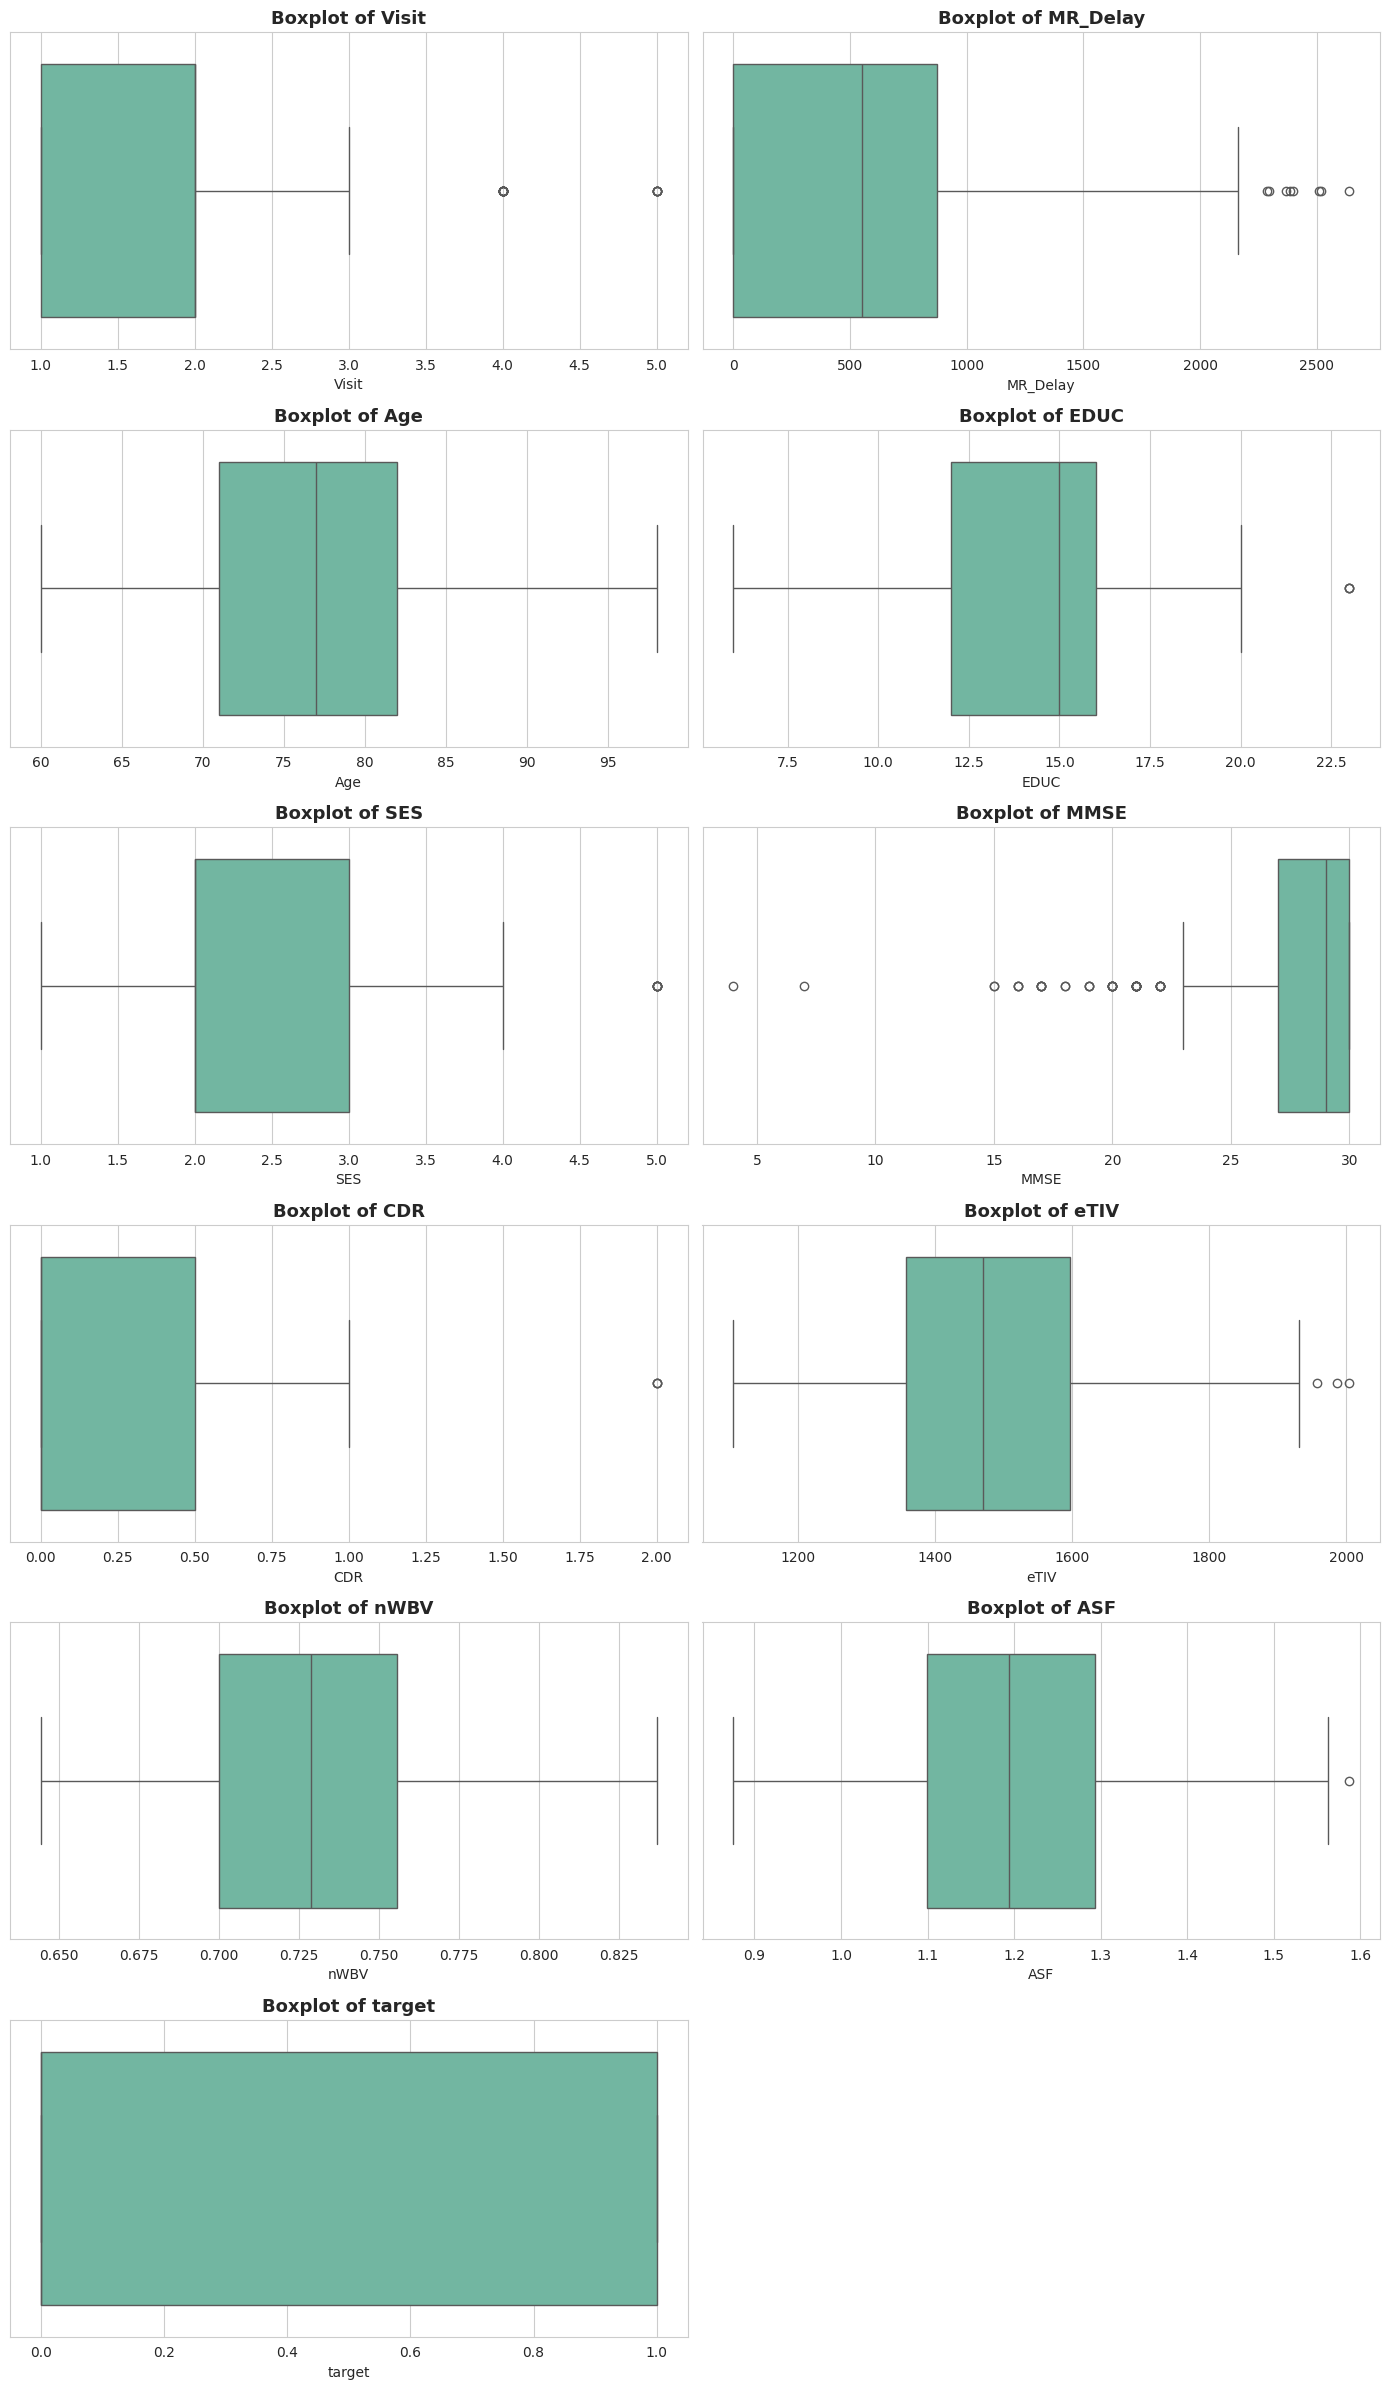

In [58]:
plot_boxplots(df, num_cols)

In [59]:
def plot_distribution(data, columns):

    rows = math.ceil(len(columns) / 2)

    fig, axes = plt.subplots(rows, 2, figsize=(14, rows*4))
    axes = axes.flatten()

    for i, col in enumerate(columns):

        sns.histplot(
            data[col],
            kde=True,
            ax=axes[i],
            bins=20,
            color="skyblue"
        )

        axes[i].set_title(f"Distribution of {col}", fontsize=13, fontweight='bold')
        axes[i].set_xlabel(col)

    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

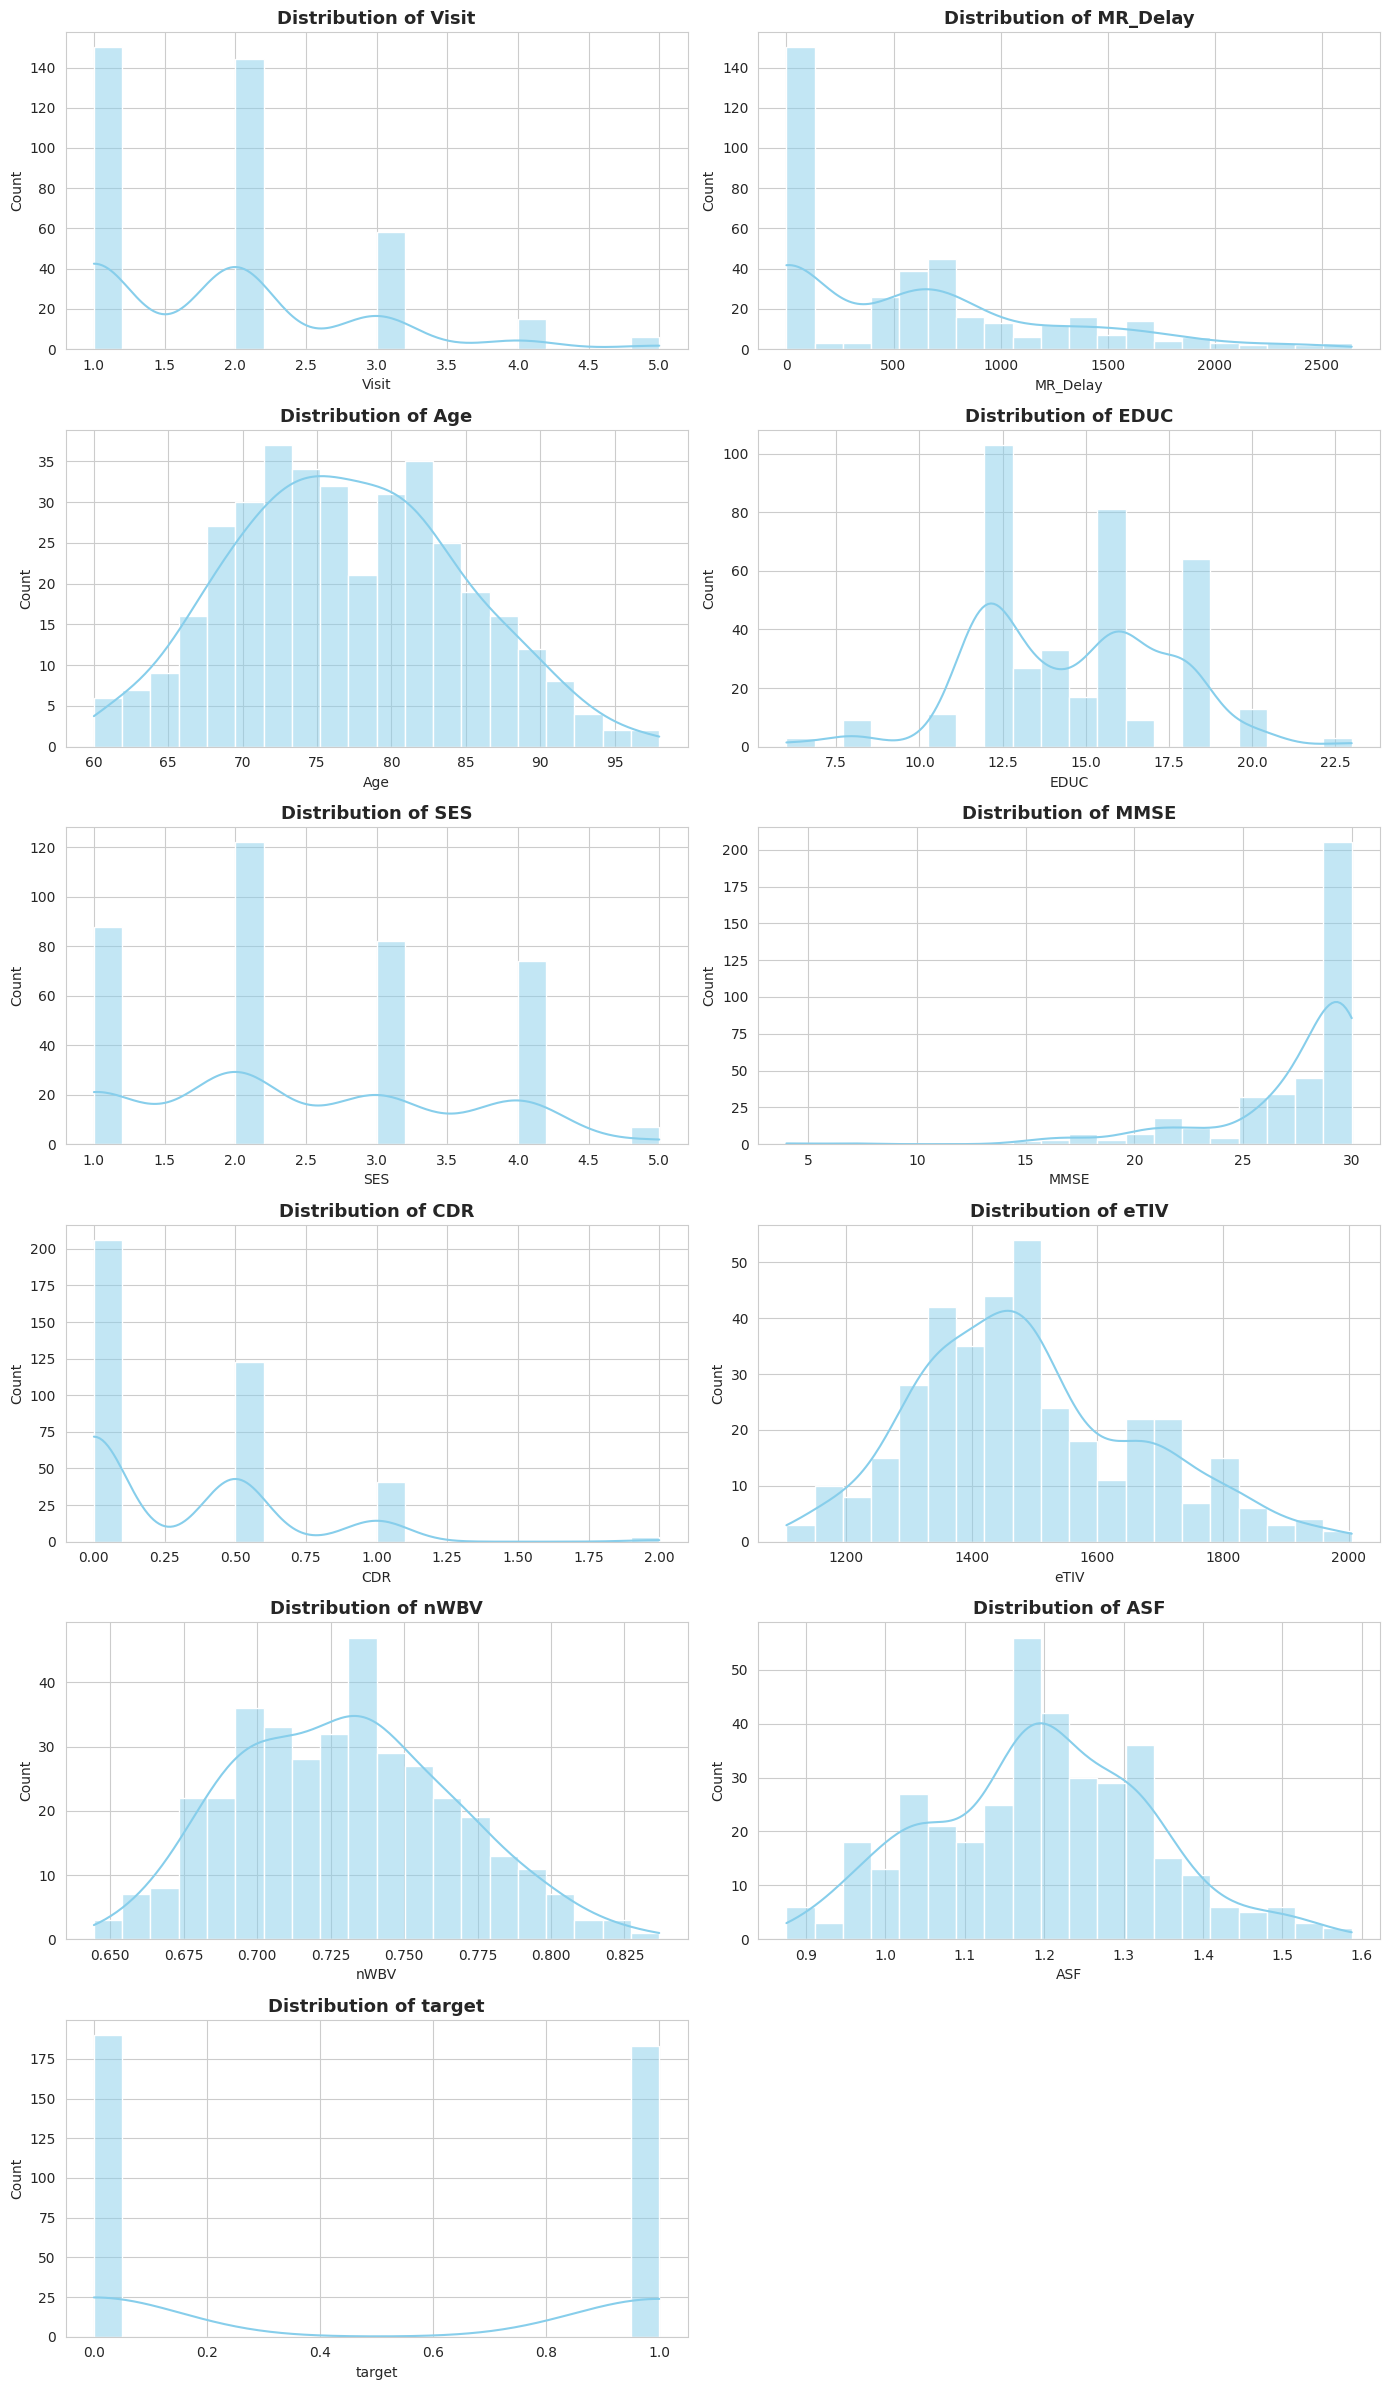

In [60]:
plot_distribution(df, num_cols)

In [61]:
def remove_outliers_iqr(data, columns):
    
    df_clean = data.copy()

    for col in columns:

        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)

        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        df_clean = df_clean[
            (df_clean[col] >= lower_bound) &
            (df_clean[col] <= upper_bound)
        ]

    return df_clean

In [62]:
# cols_with_outliers = ['Age','EDUC','SES','MMSE','eTIV','nWBV']
# df = remove_outliers_iqr(df, cols_with_outliers)

In [63]:
df["M/F"] = df["M/F"].replace({"F": 0, "M": 1}).astype(int)

##### Correlation Analysis 

- Pearson Correlation
- Heatmap


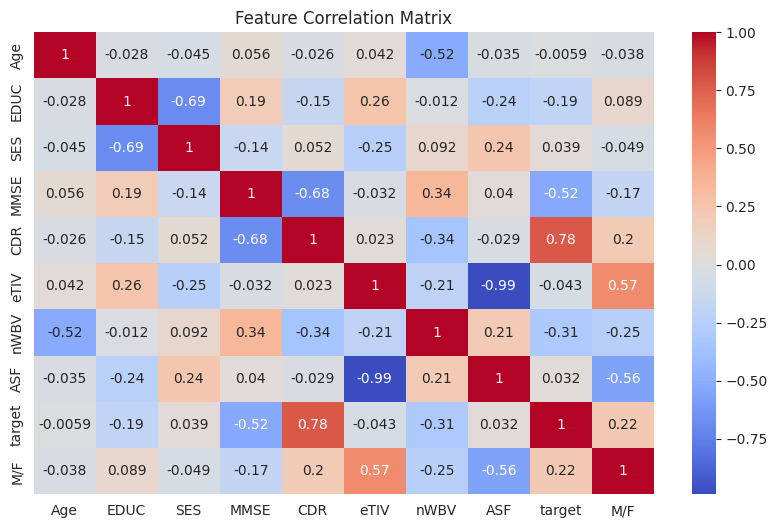

In [64]:
plt.figure(figsize=(10,6))

corr = df[['Age','EDUC','SES','MMSE','CDR','eTIV','nWBV','ASF', 'target', 'M/F']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Feature Correlation Matrix")

plt.show()

In [65]:
corr

,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF,target,M/F
Age,1.000000,-0.027886,-0.045410,0.055607,-0.026257,0.042401,-0.518546,-0.034845,-0.005941,-0.037726
EDUC,-0.027886,1.000000,-0.691222,0.194454,-0.153121,0.257042,-0.012300,-0.241696,-0.193060,0.089279
SES,-0.045410,-0.691222,1.000000,-0.139063,0.052313,-0.249026,0.092195,0.240713,0.038870,-0.048504
MMSE,0.055607,0.194454,-0.139063,1.000000,-0.679837,-0.031792,0.341860,0.039584,-0.523305,-0.166521
CDR,-0.026257,-0.153121,0.052313,-0.679837,1.000000,0.022863,-0.344873,-0.029426,0.778049,0.202140
eTIV,0.042401,0.257042,-0.249026,-0.031792,0.022863,1.000000,-0.209875,-0.988868,-0.042579,0.572589
nWBV,-0.518546,-0.012300,0.092195,0.341860,-0.344873,-0.209875,1.000000,0.213073,-0.310893,-0.249316
ASF,-0.034845,-0.241696,0.240713,0.039584,-0.029426,-0.988868,0.213073,1.000000,0.032463,-0.561648
target,-0.005941,-0.193060,0.038870,-0.523305,0.778049,-0.042579,-0.310893,0.032463,1.000000,0.222146
M/F,-0.037726,0.089279,-0.048504,-0.166521,0.202140,0.572589,-0.249316,-0.561648,0.222146,1.000000


- MMSE vs CDR (stronng negative correlation)

- Age vs nWBV (negative correlation)

- eTIV vs ASF (strong negative correlation)

###### Target Column Distribution

In [66]:
df['target'] = df['Group'].map({
    'Nondemented': 0,
    'Demented': 1,
    'Converted': 1
})

In [67]:
df['target'].value_counts()

target
0    190
1    183
Name: count, dtype: int64

In [68]:
df['target'].value_counts(normalize=True)*100

target
0    50.938338
1    49.061662
Name: proportion, dtype: float64

##### MMSE vs Alzheimer's

- MMSE = cognitive test score.

- Lower MMSE --> higher dementia risk.

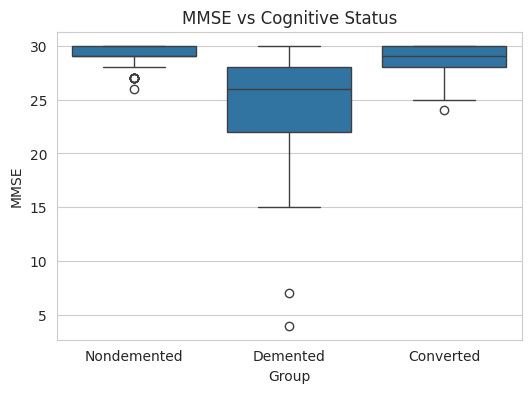

In [69]:
plt.figure(figsize=(6,4))

sns.boxplot(x='Group', y='MMSE', data=df)

plt.title("MMSE vs Cognitive Status")

plt.show()

- Demented group should have lower MMSE scores.

- This is usually one of the strongest predictors.

##### Brain Volume vs Alzheimer's

- I used nWBV (normalized whole brain volume).

- Lower brain volume --> dementia progression.

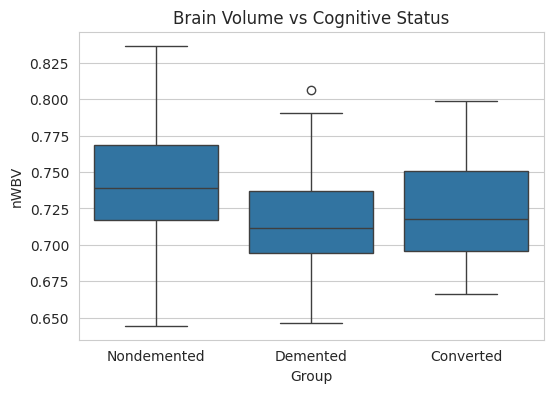

In [70]:
plt.figure(figsize=(6,4))

sns.boxplot(x='Group', y='nWBV', data=df)

plt.title("Brain Volume vs Cognitive Status")

plt.show()

##### Cognitive Decline Over Time (MMSE vs Visit)

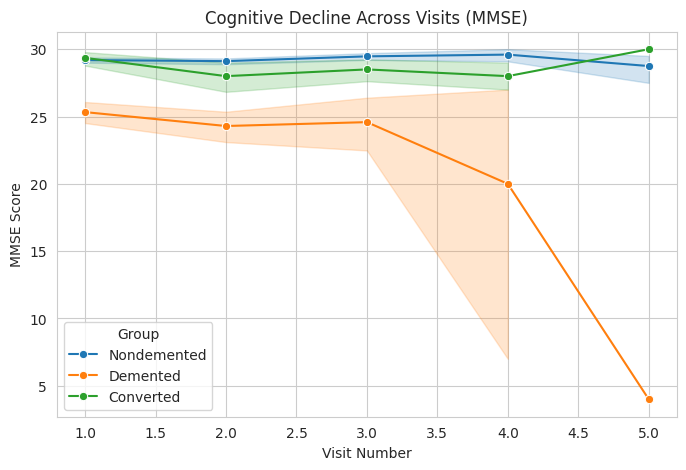

In [71]:
plt.figure(figsize=(8,5))

sns.lineplot(
    data=df,
    x='Visit',
    y='MMSE',
    hue='Group',
    marker='o'
)

plt.title("Cognitive Decline Across Visits (MMSE)")
plt.xlabel("Visit Number")
plt.ylabel("MMSE Score")

plt.show()

- Nondemented --> MMSE remains stable

- Converted --> gradual decline

- Demented --> already low MMSE

This plot strongly supports early detection modeling.

##### MMSE vs Brain Volume Relationship

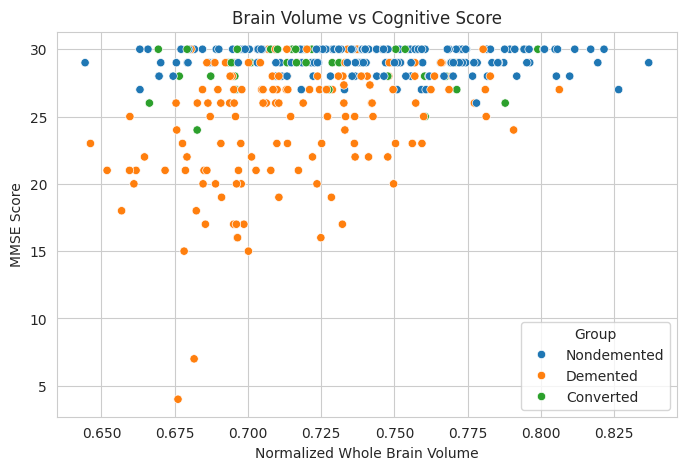

In [72]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='nWBV',
    y='MMSE',
    hue='Group'
)

plt.title("Brain Volume vs Cognitive Score")
plt.xlabel("Normalized Whole Brain Volume")
plt.ylabel("MMSE Score")

plt.show()

- This plot reveals a very strong clinical relationship.

- When brain volume decreases, cognitive ability declines.

- Higher brain volume --> higher MMSE

- Demented patients cluster in low brain volume + low MMSE region

This shows structural brain degeneration leads to cognitive decline.

### 5. Feature Engineering

In [73]:
df = df.sort_values(['Subject_ID', 'Visit'])

In [74]:
df['MMSE'].fillna(df['MMSE'].median(), inplace=True)

In [75]:
# Time Between Visits

# Create feature for time progression.
# Alzheimer’s progression depends on time.

df['time_since_first_visit'] = df.groupby('Subject_ID')['MR_Delay'].transform(lambda x: x - x.min())

##### MMSE Change
- Measure change in cognitive score between visits.
- Cognitive decline is a strong signal of Alzheimer's onset.

In [76]:
df['MMSE_change'] = df.groupby('Subject_ID')['MMSE'].diff()

In [77]:
df['MMSE'].unique()

array([27.        , 30.        , 23.        , 28.        , 22.        ,
       29.        , 24.        , 21.        , 16.        , 25.        ,
       26.        , 15.        , 20.        , 19.        ,  7.        ,
        4.        , 17.        , 18.        , 27.34231806])

In [78]:
df['MMSE_change'].fillna(0, inplace=True)

##### Brain Volume Change

- Brain volume shrinking is a biological marker.

In [79]:
df['nWBV_change'] = df.groupby('Subject_ID')['nWBV'].diff()

df['nWBV_change'].fillna(0, inplace=True)

##### MSE Decline Rate

- Instead of raw difference, calculate decline rate.

In [80]:
df['MMSE_decline_rate'] = df['MMSE_change'] / (df['MR_Delay'] + 1) # Added 1- To avoid division by zero.

##### Brain Atrophy Rate

In [81]:
df['brain_atrophy_rate'] = df['nWBV_change'] / (df['MR_Delay'] + 1)

##### Patient-Level Aggregated Features
- Instead of using raw visit data, we create patient-level features.

In [82]:
# Mean MMSE across visits.
# df['MMSE_mean'] = df.groupby('Subject_ID')['MMSE'].transform('mean')
# df['MMSE_std'] = df.groupby('Subject_ID')['MMSE'].transform('std')

In [83]:
# Brain Volume Trend
# df['nWBV_mean'] = df.groupby('Subject_ID')['nWBV'].transform('mean')
# df['nWBV_std'] = df.groupby('Subject_ID')['nWBV'].transform('std')

In [84]:
# Visit Count
# More visits → more reliable trend.

df['visit_count'] = df.groupby('Subject_ID')['Visit'].transform('count')

### 6. Model Pipeline

- Feature Selection 
- Model Building
- hyper-parameter Tunning
- SHAP Explainability

In [85]:
df['target'] = df['Group'].map({
    'Nondemented': 0,
    'Demented': 1,
    'Converted': 1
})

In [86]:
df['target'].value_counts()

target
0    190
1    183
Name: count, dtype: int64

In [87]:
df.drop(columns=['CDR', 'MMSE_change', 'M/F', 'MMSE_decline_rate'], inplace=True)

In [88]:
def treat_outliers_iqr(df, columns):

    df_out = df.copy()
    
    for col in columns:
        
        Q1 = df_out[col].quantile(0.25)
        Q3 = df_out[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Cap the outliers
        df_out[col] = np.where(df_out[col] < lower_bound, lower_bound, df_out[col])
        df_out[col] = np.where(df_out[col] > upper_bound, upper_bound, df_out[col])
    
    return df_out

In [89]:
outlier_columns = ['MR_Delay', 'eTIV', 'ASF']

df = treat_outliers_iqr(df, outlier_columns)

In [90]:
df.head()

,Subject_ID,MRI_ID,Group,Visit,MR_Delay,Age,EDUC,SES,MMSE,eTIV,nWBV,ASF,target,time_since_first_visit,nWBV_change,brain_atrophy_rate,visit_count
0,OAS2_0001,OAS2_0001_MR1,Nondemented,1,0.0,87,14,2.0,27.0,1956.346983,0.696106,0.883440,0,0,0.000000,0.000000,2
1,OAS2_0001,OAS2_0001_MR2,Nondemented,2,457.0,88,14,2.0,30.0,1956.346983,0.681062,0.875539,0,457,-0.015044,-0.000033,2
2,OAS2_0002,OAS2_0002_MR1,Demented,1,0.0,75,12,2.0,23.0,1678.290000,0.736336,1.045710,1,0,0.000000,0.000000,3
3,OAS2_0002,OAS2_0002_MR2,Demented,2,560.0,76,12,2.0,28.0,1737.620000,0.713402,1.010000,1,560,-0.022934,-0.000041,3
4,OAS2_0002,OAS2_0002_MR3,Demented,3,1895.0,80,12,2.0,22.0,1697.911134,0.701236,1.033623,1,1895,-0.012166,-0.000006,3


In [91]:
df.isna().sum()

Subject_ID                0
MRI_ID                    0
Group                     0
Visit                     0
MR_Delay                  0
Age                       0
EDUC                      0
SES                       0
MMSE                      0
eTIV                      0
nWBV                      0
ASF                       0
target                    0
time_since_first_visit    0
nWBV_change               0
brain_atrophy_rate        0
visit_count               0
dtype: int64

In [92]:
df.duplicated().sum() # No duplicat erows are available in the dataset

np.int64(0)

In [93]:


def apply_minmax_scaling(train_df, test_df):
    global scaler
    scaler = MinMaxScaler()
    
    train_scaled = scaler.fit_transform(train_df)
    test_scaled = scaler.transform(test_df)
    
    train_scaled = pd.DataFrame(train_scaled, columns=train_df.columns, index=train_df.index)
    test_scaled = pd.DataFrame(test_scaled, columns=test_df.columns, index=test_df.index)
    
    return train_scaled, test_scaled



def calculate_vif(X, threshold=10):

    features = X.columns.tolist()

    while True:
        vif = pd.DataFrame()
        vif["Feature"] = features
        vif["VIF"] = [variance_inflation_factor(X[features].values, i) for i in range(len(features))]

        max_vif = vif["VIF"].max()

        if max_vif > threshold:
            remove_feature = vif.sort_values("VIF", ascending=False)["Feature"].iloc[0]
            print(f"Removing feature due to high VIF: {remove_feature} (VIF={max_vif:.2f})")
            features.remove(remove_feature)
        else:
            break

    print("\nFinal Features after VIF Selection:")
    print(features)

    return features


def train_and_evaluate_models(df, target_column='target', group_column='Subject_ID'):
    
    # Initial Feature List
    feature_cols = [
        'Age',
        'EDUC',
        'SES',
        'MR_Delay',
        'eTIV',
        'nWBV',
        'ASF',
        'time_since_first_visit',
        'nWBV_change',
        'brain_atrophy_rate',
        'visit_count'
    ]
    
    X = df[feature_cols]
    y = df[target_column]
    groups = df[group_column]
    
    
    # VIF Feature Selection
    selected_features = calculate_vif(X)
    
    X = X[selected_features]
    
    
    # Group Based Train-Test Split
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, test_idx = next(gss.split(X, y, groups))
    
    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]
    
    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]
    
    # Apply MinMax Scaling
    X_train, X_test = apply_minmax_scaling(X_train, X_test)
    
    
    # Define Models
    global models
    models = {
        "Logistic Regression": LogisticRegression(max_iter=1000),
        "Decision Tree": DecisionTreeClassifier(random_state=42),
        "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
        "AdaBoost": AdaBoostClassifier(random_state=42)
    }
    
    
    evaluation_results = []
    confusion_results = []
    feature_importance_results = []
    
    
    # Train & Evaluate Models
    for name, model in models.items():
        
        print(f"\nTraining {name} ...")
        
        model.fit(X_train, y_train)
        
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:,1]
        
        
        # Evaluation Metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_prob)
        
        
        evaluation_results.append({
            "Model": name,
            "Accuracy": round(accuracy,4),
            "Precision": round(precision,4),
            "Recall": round(recall,4),
            "F1 Score": round(f1,4),
            "ROC AUC": round(auc,4)
        })
        
        
        # Confusion Matrix
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        
        confusion_results.append({
            "Model": name,
            "TP": tp,
            "TN": tn,
            "FP": fp,
            "FN": fn
        })
        
        
        # Feature Importance
        if hasattr(model, "feature_importances_"):
            importances = model.feature_importances_
        else:
            importances = abs(model.coef_[0])
        
        
        for feature, importance in zip(selected_features, importances):
            feature_importance_results.append({
                "Model": name,
                "Feature": feature,
                "Importance": round(importance,5)
            })
        
        
    evaluation_df = pd.DataFrame(evaluation_results)
    confusion_df = pd.DataFrame(confusion_results)
    feature_importance_df = pd.DataFrame(feature_importance_results)
    
    
    return evaluation_df, confusion_df, feature_importance_df

In [94]:
final_feature_cols = [
        'Age',
        'EDUC',
        'SES',
        'MR_Delay',
        'eTIV',
        'nWBV',
        'ASF',
        'time_since_first_visit',
        'nWBV_change',
        'brain_atrophy_rate',
        'visit_count'
    ]
evaluation_report, confusion_report, feature_importance_report = train_and_evaluate_models(df)

Removing feature due to high VIF: MR_Delay (VIF=599.59)
Removing feature due to high VIF: nWBV (VIF=581.48)
Removing feature due to high VIF: Age (VIF=110.29)
Removing feature due to high VIF: EDUC (VIF=53.13)
Removing feature due to high VIF: eTIV (VIF=25.86)
Removing feature due to high VIF: ASF (VIF=15.35)

Final Features after VIF Selection:
['SES', 'time_since_first_visit', 'nWBV_change', 'brain_atrophy_rate', 'visit_count']

Training Logistic Regression ...

Training Decision Tree ...

Training Random Forest ...

Training AdaBoost ...


In [95]:
evaluation_report

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.5789,0.4667,0.7241,0.5676,0.4982
1,Decision Tree,0.5658,0.4524,0.6552,0.5352,0.5602
2,Random Forest,0.5263,0.4286,0.7241,0.5385,0.5290
3,AdaBoost,0.5263,0.4000,0.4828,0.4375,0.5246


In [96]:
confusion_report

,Model,TP,TN,FP,FN
0,Logistic Regression,21,23,24,8
1,Decision Tree,19,24,23,10
2,Random Forest,21,19,28,8
3,AdaBoost,14,26,21,15


In [97]:
feature_importance_report

,Model,Feature,Importance
0,Logistic Regression,SES,0.89212
1,Logistic Regression,time_since_first_visit,0.62893
2,Logistic Regression,nWBV_change,0.41430
3,Logistic Regression,brain_atrophy_rate,0.97112
4,Logistic Regression,visit_count,1.31746
5,Decision Tree,SES,0.10643
6,Decision Tree,time_since_first_visit,0.35313
7,Decision Tree,nWBV_change,0.20647
8,Decision Tree,brain_atrophy_rate,0.23715
9,Decision Tree,visit_count,0.09682


In [98]:
feature_importance_report.sort_values(by=['Model', 'Importance'], ascending=False)

,Model,Feature,Importance
13,Random Forest,brain_atrophy_rate,0.26000
11,Random Forest,time_since_first_visit,0.25394
12,Random Forest,nWBV_change,0.22088
10,Random Forest,SES,0.13431
14,Random Forest,visit_count,0.13087
4,Logistic Regression,visit_count,1.31746
3,Logistic Regression,brain_atrophy_rate,0.97112
0,Logistic Regression,SES,0.89212
1,Logistic Regression,time_since_first_visit,0.62893
2,Logistic Regression,nWBV_change,0.41430


In [99]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_feature_importance(feature_importance_report):
    
    models = feature_importance_report['Model'].unique()
    
    for model in models:
        
        model_df = feature_importance_report[
            feature_importance_report['Model'] == model
        ].sort_values(by='Importance', ascending=False)
        
        
        plt.figure(figsize=(8,5))
        
        sns.barplot(
            data=model_df,
            x='Importance',
            y='Feature'
        )
        
        plt.title(f'Feature Importance - {model}')
        plt.xlabel('Importance')
        plt.ylabel('Feature')
        
        plt.tight_layout()
        plt.show()

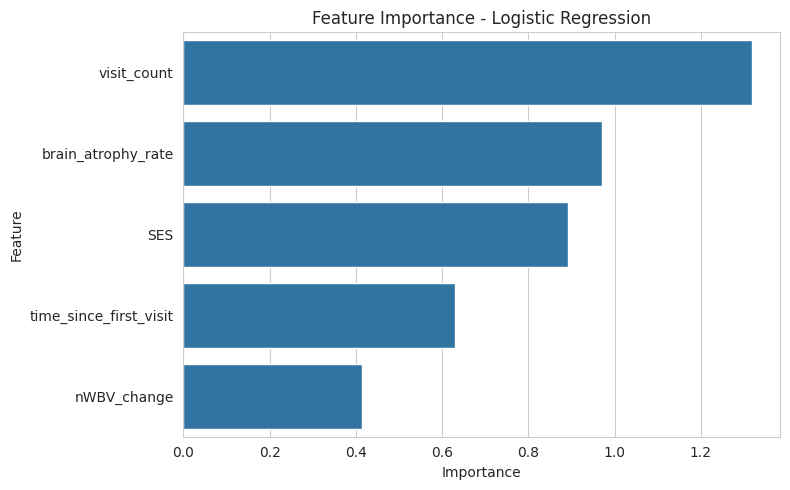

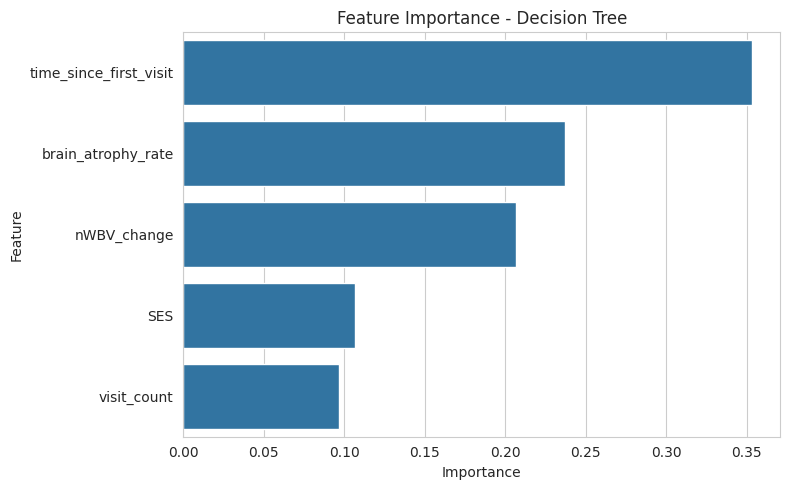

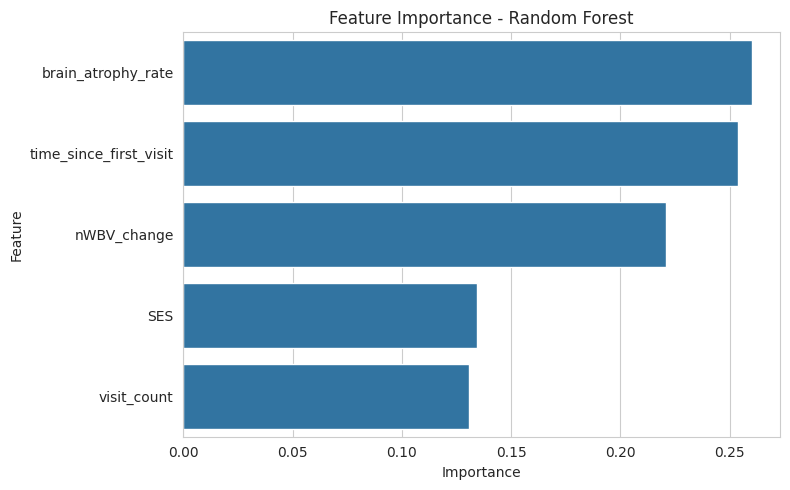

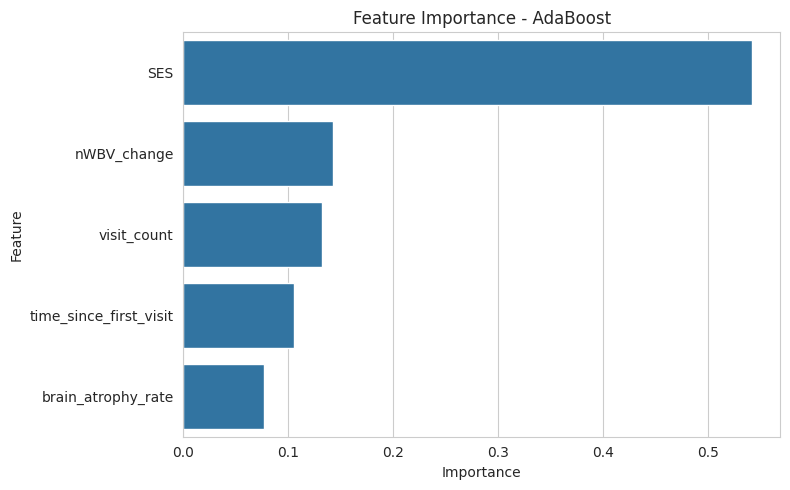

In [100]:
plot_feature_importance(feature_importance_report)

In [101]:
def save_trained_model(model, model_name, directory="trained_models"):
    
    # Create directory if it does not exist
    os.makedirs(directory, exist_ok=True)
    
    model_path = os.path.join(directory, f"{model_name}.pkl")
    
    # Save model
    joblib.dump(model, model_path)
    
    print(f"Model saved at: {model_path}")

In [102]:
save_trained_model(models['Logistic Regression'], "logistic_model")
joblib.dump(scaler, "trained_models/minmax_scaler.pkl")

Model saved at: trained_models/logistic_model.pkl


['trained_models/minmax_scaler.pkl']

 ---